## Interpolasi

Interpolasi adalah metode untuk menghitung atau mengestimasi suatu nilai diantara nilai yang sudah diketahui. Misalnya, suatu data kecepatan objek terhadap waktu adalah sebagai berikut

|Waktu (s)|Kecepatan (m/s)|
|:--:|:--:|
|5|40|
|10|45|
|15|55|

pertanyaanya, berapa kecepatan objek pada saat 12 detik? Kita bisa menggunakan pendekatan interpolasi untuk menjawab permasalahan ini.

### Interpolasi Linear

Metode sederhana interpolasi adalah interpolasi linear. Asumsinya, perubahan yang terjadi pada suatu data adalah linear. Metode ini didefinisikan dalam bentuk persamaan sebagai berikut

$y(x) = y_i + \frac {(y_{i+1} - y_i)(x - x_i)}{x_{i+1} - x_i}$

dimana $i = 0,1,2,3,...n$

Kita implementasikan menggunakan contoh tabel di atas, dimana $x$ adalah waktu dan $y$ adalah kecepatan. Ketika $x=6$ dan $i=0$, maka

$y(x=6) = y_0 + \frac {(y_{0+1} - y_0)(x - x_0)}{x_{0+1} - x_0}$

$y(x=6) = 40 + \frac {(45 - 40)(6 - 5)}{10 - 5}$

$y(x=6) = 40 + \frac {5 * 1}{5}$

$y(x=6) = 40 + 1 = 41$ $m/s$

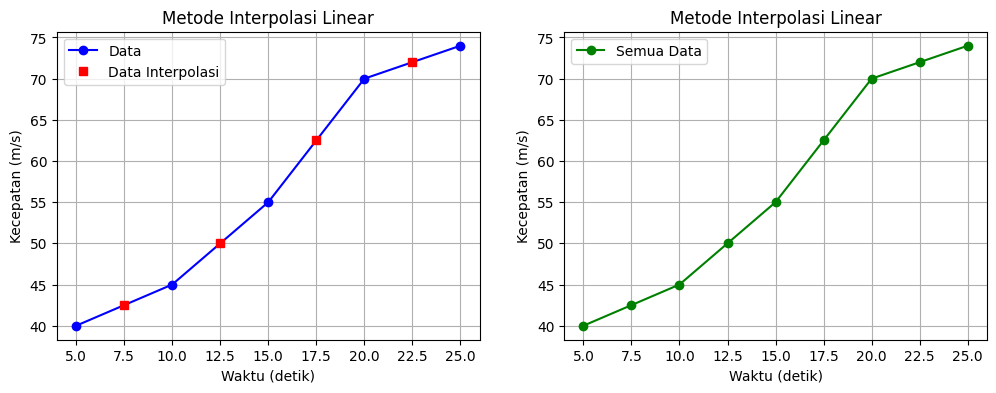

In [5]:
# Metode Interpolasi Linear

t_data = [5,10,15,20,25]
v_data = [40,45,55,70,74]
n = len(v_data)

waktu_interpolasi, waktu_semua_data = [], []
kecepatan_interpolasi, kecepatan_semua_data = [], []
dt = 2.5
t = t_data[0] + dt
for i in range(n-1):
  kecepatan_semua_data.append(v_data[i])
  waktu_semua_data.append(t_data[i])

  y = v_data[i] + ((v_data[i+1] - v_data[i]) * (t - t_data[i]))/(t_data[i+1]-t_data[i])

  # Simpan hasil interpolasi yang baru
  kecepatan_interpolasi.append(y)
  waktu_interpolasi.append(t)

  kecepatan_semua_data.append(y)
  waktu_semua_data.append(t)

  # perbaharui nilai t
  t = t_data[i+1] + dt

kecepatan_semua_data.append(v_data[-1])
waktu_semua_data.append(t_data[-1])

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4), ncols=2)
ax[0].plot(t_data, v_data, 'b-o', label='Data')
ax[0].plot(waktu_interpolasi, kecepatan_interpolasi, 'rs', label='Data Interpolasi')
ax[0].set(xlabel='Waktu (detik)', ylabel='Kecepatan (m/s)', title='Metode Interpolasi Linear', axisbelow=True)
ax[0].grid()
ax[0].legend()

ax[1].plot(waktu_semua_data, kecepatan_semua_data, 'g-o', label='Semua Data')
ax[1].set(xlabel='Waktu (detik)', ylabel='Kecepatan (m/s)', title='Metode Interpolasi Linear', axisbelow=True)
ax[1].grid()
ax[1].legend()

### Interpolasi Lagarange

Interpolasi Lagrange adalah salah satu metode yang digunakan untuk menentukan suatu nilai dari sebaran data yang diketahui yang membentuk suatu fungsi polinomial. Secara numerik, metode ini ditulis

$$P(x) = \Sigma_{j=0}^n y_j L_j (x)$$

dimana $n$ adalah banyaknya suuatu data, $y_i$ adalah kumpulan data yang diketahui, dan $L_j(x)$ adalah bentuk polinomial yang didefinisikan sebagai berikut

$$L_j(x) = \Pi_{k=0, k \ne j}^n \frac {x - x_k}{x_j - x_k}$$

dan $x$ adalah nilai yang ingin diinterpolasi.

Kita gunakan data berikut sebagai contoh interpolasi menggunakan metode Interpolasi Lagrange

|Waktu (s)|Kecepatan (m/s)|
|:--:|:--:|
|5|40|
|10|45|
|15|55|

Berapa nilai kecepatan ketika waktu 12 detik?

Berdasarkan contoh di atas, jumlah data yang tersedia adalah $n=3$ dan nilai yang ingin diketahui hasil interpolasinya adalah $x=12$, maka kita hitung polinomial ($L_j(x)$) untuk setiap komponen data berdasarkan nilai $x$ yang diketahui

n = 0
- j = 0, dan k = 0. Tetapi, karena $k \ne j$, maka $k=1$

  $L_{j=0}(x=12) = \frac {x - x_k}{x_j - x_k} = \frac {x - x_1}{x_0 - x_1} = \frac {12 - 10}{5 - 10} = \frac {2}{-5} = -0.4$

- j = 0, dan k = 2

  $L_{j=0}(x=12) = \frac {x - x_k}{x_j - x_k} = \frac {x - x_2}{x_0 - x_2} = \frac {12 - 15}{5 - 15} = \frac {-3}{-10} = 0.3$

  $L_{j=0} = -0.4 * 0.3 = -0.12$

n = 1

- j = 1, dan k = 0

  $L_{j=1}(x=12) = \frac {x - x_k}{x_j - x_k} = \frac {x - x_0}{x_1 - x_0} = \frac {12 - 5}{10 - 5} = \frac {7}{5} = 1.4$

- j = 1, dan k = 1. Tetapi $k \ne j$, maka k = 2

  $L_{j=1}(x=12) = \frac {x - x_k}{x_j - x_k} = \frac {x - x_2}{x_1 - x_2} = \frac {12 - 15}{10 - 15} = \frac {-3}{-5} = 0.6$

  $L_{j=1} = 1.4 * 0.6 = 0.84$

n = 3

- j = 2, dan k = 0

  $L_{j=2}(x=12) = \frac {x - x_k}{x_j - x_k} = \frac {x - x_0}{x_2 - x_0} = \frac {12 - 5}{15 - 5} = \frac {7}{10} = 0.7$

- j = 2, dan k = 1

  $L_{j=2}(x=12) = \frac {x - x_k}{x_j - x_k} = \frac {x - x_1}{x_2 - x_1} = \frac {12 - 10}{15 - 10} = \frac {2}{5} = 0.4$

  $L_{j=2} = 0.7 * 0.4 = 0.28$

Kemudian hitung $P(x)$

$P(x=12) = L_0 * y_0 + L_1 * y_1 + L_2 * y_2$

$P(x=12) = -0.12 * 40 + 0.84 * 45 + 0.28 * 55$

$P(x=12) = -4.8 + 37.8 + 15.4 = 48.4$

Jika terdapat $n$ titik data, maka pada perhitungan polinomial, $L_j (x)$, titik data yang digunakan adalah $n-1$. Kemudian kita coba implementasikan ke dalam kode program Python sebagai berikut.


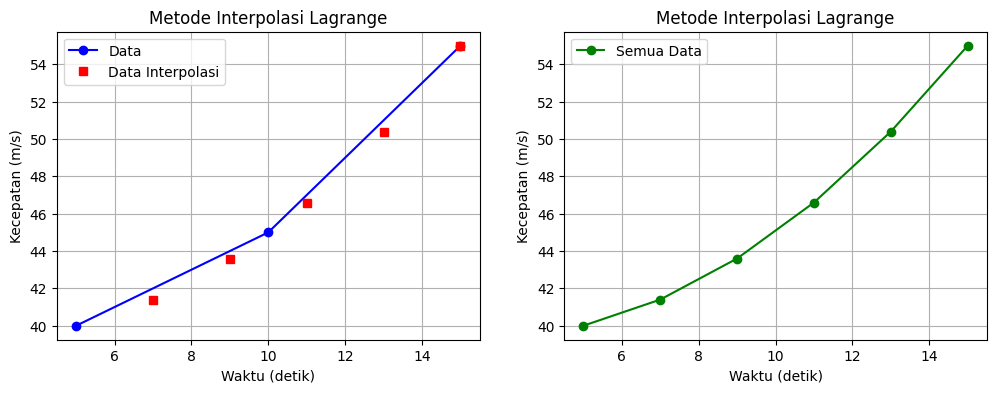

In [4]:
# Metode Interpolasi Lagrange

t_data = [5,10,15]
v_data = [40,45,55]
n = len(v_data)

dt = 2
t = t_data[0] + dt
# t = 12

waktu_interpolasi, kecepatan_interpolasi = [], []
waktu_semua_data, kecepatan_semua_data = [t_data[0]], [v_data[0]]

while t <= t_data[-1]:
  waktu_interpolasi.append(t)
  waktu_semua_data.append(t)
  # Pengulangan untuk menjumlahkan semua polinomial
  P = 0
  for j in range(n):
    L = 1
    for k in range(n):
      if k == j:
        continue
      else:
        L = L * ((t - t_data[k])/(t_data[j] - t_data[k]))

    # Hitung penjumlahan polinomial
    P = P + (v_data[j] * L)

  kecepatan_interpolasi.append(P)
  kecepatan_semua_data.append(P)

  t += dt

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(12,4), ncols=2)
ax[0].plot(t_data, v_data, 'b-o', label='Data')
ax[0].plot(waktu_interpolasi, kecepatan_interpolasi, 'rs', label='Data Interpolasi')
ax[0].set(xlabel='Waktu (detik)', ylabel='Kecepatan (m/s)', title='Metode Interpolasi Lagrange', axisbelow=True)
ax[0].grid()
ax[0].legend()

ax[1].plot(waktu_semua_data, kecepatan_semua_data, 'g-o', label='Semua Data')
ax[1].set(xlabel='Waktu (detik)', ylabel='Kecepatan (m/s)', title='Metode Interpolasi Lagrange', axisbelow=True)
ax[1].grid()
ax[1].legend()